In [1]:
import pandas as pd
import numpy as np

df = pd.read_excel("dataset.xlsx")

print(f"{df.shape} \n\n")
print(f"{df.head()} \n\n")
print(f"{df.info()} ")

(16969, 10) 


   Age  Blood Glucose Level(BGL)  Diastolic Blood Pressure  \
0    9                        79                        73   
1    9                        80                        73   
2    9                        70                        76   
3    9                        70                        78   
4   66                       100                        96   

   Systolic Blood Pressure  Heart Rate  Body Temperature  SPO2  \
0                      118          98         98.300707    99   
1                      119         102         98.300707    94   
2                      110          81         98.300707    98   
3                      115          96         98.300707    96   
4                      144          92         97.807052    98   

   Sweating  (Y/N)  Shivering (Y/N) Diabetic/NonDiabetic (D/N)  
0                0                0                          N  
1                1                0                          N  
2                1  

In [2]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())

['Age', 'Blood Glucose Level(BGL)', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)', 'Shivering (Y/N)', 'Diabetic/NonDiabetic (D/N)']


In [3]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates().reset_index(drop=True)
print(df.shape)
print(df["Age"].nunique())
print(sorted(df["Age"].unique().tolist()))

Duplicates: 272
(16697, 10)
13
[9, 14, 15, 19, 30, 36, 44, 46, 51, 55, 66, 76, 77]


In [4]:
print(df.isnull().sum())

Age                           0
Blood Glucose Level(BGL)      0
Diastolic Blood Pressure      0
Systolic Blood Pressure       0
Heart Rate                    0
Body Temperature              0
SPO2                          0
Sweating  (Y/N)               0
Shivering (Y/N)               0
Diabetic/NonDiabetic (D/N)    0
dtype: int64


In [5]:
df['Diabetic/NonDiabetic (D/N)'] = (
    df['Diabetic/NonDiabetic (D/N)']
    .map({'D': 1, 'N': 0})
)
print(df['Diabetic/NonDiabetic (D/N)'].value_counts())

Diabetic/NonDiabetic (D/N)
1    16369
0      328
Name: count, dtype: int64


In [6]:
features = [
    'Age',
    'Diastolic Blood Pressure',
    'Systolic Blood Pressure',
    'Heart Rate',
    'Body Temperature',
    'SPO2',
    'Sweating  (Y/N)',
    'Shivering (Y/N)',
    'Diabetic/NonDiabetic (D/N)'
]

target = 'Blood Glucose Level(BGL)'

print(df.columns.tolist())

['Age', 'Blood Glucose Level(BGL)', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)', 'Shivering (Y/N)', 'Diabetic/NonDiabetic (D/N)']


In [7]:
X = df[features]
y = df[target]

print(X.head())
print(y.head())

   Age  Diastolic Blood Pressure  Systolic Blood Pressure  Heart Rate  \
0    9                        73                      118          98   
1    9                        73                      119         102   
2    9                        76                      110          81   
3    9                        78                      115          96   
4   66                        96                      144          92   

   Body Temperature  SPO2  Sweating  (Y/N)  Shivering (Y/N)  \
0         98.300707    99                0                0   
1         98.300707    94                1                0   
2         98.300707    98                1                0   
3         98.300707    96                1                0   
4         97.807052    98                0                0   

   Diabetic/NonDiabetic (D/N)  
0                           0  
1                           0  
2                           0  
3                           0  
4                     

In [12]:

from sklearn.model_selection import train_test_split

stratify_age = df["Age"]
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=stratify_age
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=X_temp["Age"]
)

print("TRAIN")
print(X_train['Diabetic/NonDiabetic (D/N)'].value_counts(normalize=True))

print("\nVALIDATION")
print(X_val['Diabetic/NonDiabetic (D/N)'].value_counts(normalize=True))

print("\nTEST")
print(X_test['Diabetic/NonDiabetic (D/N)'].value_counts(normalize=True))

print("Train:")
print(X_train['Diabetic/NonDiabetic (D/N)'].value_counts())

print("\nValidation:")
print(X_val['Diabetic/NonDiabetic (D/N)'].value_counts())

print("\nTest:")
print(X_test['Diabetic/NonDiabetic (D/N)'].value_counts())

TRAIN
Diabetic/NonDiabetic (D/N)
1    0.980234
0    0.019766
Name: proportion, dtype: float64

VALIDATION
Diabetic/NonDiabetic (D/N)
1    0.983234
0    0.016766
Name: proportion, dtype: float64

TEST
Diabetic/NonDiabetic (D/N)
1    0.978044
0    0.021956
Name: proportion, dtype: float64
Train:
Diabetic/NonDiabetic (D/N)
1    11456
0      231
Name: count, dtype: int64

Validation:
Diabetic/NonDiabetic (D/N)
1    2463
0      42
Name: count, dtype: int64

Test:
Diabetic/NonDiabetic (D/N)
1    2450
0      55
Name: count, dtype: int64


In [13]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

rf_val_pred = rf.predict(X_val)

In [14]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    objective='reg:squarederror',
    n_estimators=1000,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

xgb.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_val_pred = xgb.predict(X_val)

In [15]:
from lightgbm import LGBMRegressor

lgbm = LGBMRegressor(
    objective='regression',
    n_estimators=1000,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

lgbm.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)]
)

lgbm_val_pred = lgbm.predict(X_val)

c:\Users\C45629B\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\lightgbm\sklearn.py:1106: LGBMDeprecationWarning: The argument 'eval_set' is deprecated, use 'eval_X' and 'eval_y' instead.
  eval_set = _validate_eval_set_Xy(eval_set=eval_set, eval_X=eval_X, eval_y=eval_y)


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000252 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 424
[LightGBM] [Info] Number of data points in the train set: 11687, number of used features: 9
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 95.934628


In [16]:
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    loss_function='RMSE',
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    random_seed=42,
    verbose=False
)

cat.fit(
    X_train,
    y_train,
    eval_set=(X_val, y_val),
    verbose=False
)

cat_val_pred = cat.predict(X_val)

In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    return rmse, mae, r2

In [18]:
results = {}

predictions = {
    'Random Forest': rf_val_pred,
    'XGBoost': xgb_val_pred,
    'LightGBM': lgbm_val_pred,
    'CatBoost': cat_val_pred
}

for name, pred in predictions.items():

    rmse, mae, r2 = evaluate_model(y_val, pred)

    results[name] = {
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }

results_df = pd.DataFrame(results).T

print(results_df)

                    RMSE        MAE        R2
Random Forest  40.170604  22.434349  0.218076
XGBoost        41.052546  23.117970  0.183365
LightGBM       40.585081  22.564523  0.201857
CatBoost       39.997414  22.079428  0.224804


In [19]:
print("Number of unique ages:", df["Age"].nunique())

print("\nRows per age:")
print(df.groupby("Age").size().sort_index())

print("\nDiabetic status for each age:")
print(
    df.groupby("Age")["Diabetic/NonDiabetic (D/N)"]
      .unique()
      .sort_index()
)

Number of unique ages: 13

Rows per age:
Age
9     6212
14    2283
15     277
19    1218
30      98
36      58
44      29
46    1922
51      28
55    1860
66      20
76    2462
77     230
dtype: int64

Diabetic status for each age:
Age
9     [0, 1]
14       [1]
15       [1]
19       [1]
30       [0]
36       [0]
44       [0]
46    [0, 1]
51       [0]
55       [1]
66       [0]
76       [1]
77       [1]
Name: Diabetic/NonDiabetic (D/N), dtype: object


In [21]:
# Number of observations for each Age + Diabetic Status combination
age_diabetic = pd.crosstab(
    df["Age"],
    df["Diabetic/NonDiabetic (D/N)"]
)

print(age_diabetic)

Diabetic/NonDiabetic (D/N)   0     1
Age                                 
9                           77  6135
14                           0  2283
15                           0   277
19                           0  1218
30                          98     0
36                          58     0
44                          29     0
46                          18  1904
51                          28     0
55                           0  1860
66                          20     0
76                           0  2462
77                           0   230


In [22]:
print("\nDetailed counts:")

print(
    df.groupby(
        ["Age", "Diabetic/NonDiabetic (D/N)"]
    )["Blood Glucose Level(BGL)"]
    .agg(["count", "mean", "std", "min", "max"])
)


Detailed counts:
                                count        mean        std  min  max
Age Diabetic/NonDiabetic (D/N)                                        
9   0                              77   77.675325   4.435033   70   85
    1                            6135   99.189242  45.182608   51  250
14  1                            2283   89.800701  41.943110   50  250
15  1                             277   98.411552  49.395149   50  250
19  1                            1218   92.089491  45.475189   50  250
30  0                              98   77.561224   4.206197   70   85
36  0                              58   76.965517   4.456281   70   85
44  0                              29   77.310345   4.504787   70   85
46  0                              18  100.000000   0.000000  100  100
    1                            1904   98.226891  41.679545   50  250
51  0                              28  100.000000   0.000000  100  100
55  1                            1860   91.516129  38.46134

In [23]:
print("X columns:")
print(X.columns.tolist())

print("\nNumber of features:", X.shape[1])

print("\nX_train columns:")
print(X_train.columns.tolist())

print("\nX_train shape:")
print(X_train.shape)

print("\nDiabetic status in X_train:")
print(X_train["Diabetic/NonDiabetic (D/N)"].value_counts())

X columns:
['Age', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)', 'Shivering (Y/N)', 'Diabetic/NonDiabetic (D/N)']

Number of features: 9

X_train columns:
['Age', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)', 'Shivering (Y/N)', 'Diabetic/NonDiabetic (D/N)']

X_train shape:
(11687, 9)

Diabetic status in X_train:
Diabetic/NonDiabetic (D/N)
1    11456
0      231
Name: count, dtype: int64


In [24]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Create validation results dataframe
val_results = X_val.copy()

val_results["Actual_BGL"] = y_val.values
val_results["Predicted_BGL"] = cat_val_pred

# Calculate errors
val_results["Error"] = (
    val_results["Actual_BGL"] -
    val_results["Predicted_BGL"]
)

val_results["Absolute_Error"] = (
    val_results["Error"].abs()
)

# Evaluate separately for D and N
for status in [0, 1]:

    group = val_results[
        val_results["Diabetic/NonDiabetic (D/N)"] == status
    ]

    rmse = np.sqrt(
        mean_squared_error(
            group["Actual_BGL"],
            group["Predicted_BGL"]
        )
    )

    mae = mean_absolute_error(
        group["Actual_BGL"],
        group["Predicted_BGL"]
    )

    r2 = r2_score(
        group["Actual_BGL"],
        group["Predicted_BGL"]
    )

    print("\nStatus:", "Non-Diabetic" if status == 0 else "Diabetic")
    print("Number of samples:", len(group))
    print("Actual BGL mean:", group["Actual_BGL"].mean())
    print("Predicted BGL mean:", group["Predicted_BGL"].mean())
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)


Status: Non-Diabetic
Number of samples: 42
Actual BGL mean: 80.38095238095238
Predicted BGL mean: 82.32042320309952
RMSE: 8.464073280609009
MAE : 7.376349553711627
R²  : 0.19459870506824306

Status: Diabetic
Number of samples: 2463
Actual BGL mean: 97.61753958587089
Predicted BGL mean: 96.45446237664294
RMSE: 40.321851830521894
MAE : 22.330150825197023
R²  : 0.2229804069836524


In [25]:
print("\nOverall validation BGL:")
print(y_val.describe())

print("\nValidation BGL by diabetic status:")
print(
    val_results.groupby(
        "Diabetic/NonDiabetic (D/N)"
    )["Actual_BGL"].describe()
)


Overall validation BGL:
count    2505.000000
mean       97.328543
std        45.437334
min        50.000000
25%        68.000000
50%        84.000000
75%       108.000000
max       250.000000
Name: Blood Glucose Level(BGL), dtype: float64

Validation BGL by diabetic status:
                             count       mean        std   min   25%   50%  \
Diabetic/NonDiabetic (D/N)                                                   
0                             42.0  80.380952   9.545660  70.0  75.0  77.0   
1                           2463.0  97.617540  45.752272  50.0  68.0  84.0   

                              75%    max  
Diabetic/NonDiabetic (D/N)                
0                            81.0  100.0  
1                           109.0  250.0  


In [26]:
# Create BGL ranges for validation data
val_results["BGL_Range"] = pd.cut(
    val_results["Actual_BGL"],
    bins=[49, 69, 89, 109, 129, 159, 199, 250],
    labels=[
        "50-69",
        "70-89",
        "90-109",
        "110-129",
        "130-159",
        "160-199",
        "200-250"
    ],
    include_lowest=True
)

# Evaluate CatBoost in each BGL range
range_results = []

for bgl_range, group in val_results.groupby(
    "BGL_Range",
    observed=True
):
    
    if len(group) == 0:
        continue

    rmse = np.sqrt(
        mean_squared_error(
            group["Actual_BGL"],
            group["Predicted_BGL"]
        )
    )

    mae = mean_absolute_error(
        group["Actual_BGL"],
        group["Predicted_BGL"]
    )

    r2 = r2_score(
        group["Actual_BGL"],
        group["Predicted_BGL"]
    ) if len(group) > 1 else np.nan

    range_results.append([
        bgl_range,
        len(group),
        group["Actual_BGL"].mean(),
        group["Predicted_BGL"].mean(),
        rmse,
        mae,
        r2
    ])

range_df = pd.DataFrame(
    range_results,
    columns=[
        "BGL Range",
        "Samples",
        "Actual Mean",
        "Predicted Mean",
        "RMSE",
        "MAE",
        "R2"
    ]
)

print(range_df)

  BGL Range  Samples  Actual Mean  Predicted Mean        RMSE         MAE  \
0     50-69      750    64.920000       67.636038    9.947540    4.896100   
1     70-89      697    79.873745      105.429733   27.989659   25.779646   
2    90-109      463    99.578834      109.940791   14.488081   11.955071   
3   110-129      418   119.179426      110.592807   12.440802   10.268298   
4   200-250      177   245.898305      111.202635  134.989872  134.695670   

            R2  
0    -4.574555  
1   -30.667804  
2    -5.394276  
3    -3.555516  
4 -4298.483009  


In [27]:
# Sort validation predictions by actual BGL
high_bgl = val_results[
    val_results["Actual_BGL"] >= 200
].sort_values("Actual_BGL")

print(
    high_bgl[
        [
            "Age",
            "Diastolic Blood Pressure",
            "Systolic Blood Pressure",
            "Heart Rate",
            "Body Temperature",
            "SPO2",
            "Sweating  (Y/N)",
            "Shivering (Y/N)",
            "Diabetic/NonDiabetic (D/N)",
            "Actual_BGL",
            "Predicted_BGL",
            "Error"
        ]
    ].to_string(index=False)
)

 Age  Diastolic Blood Pressure  Systolic Blood Pressure  Heart Rate  Body Temperature  SPO2  Sweating  (Y/N)  Shivering (Y/N)  Diabetic/NonDiabetic (D/N)  Actual_BGL  Predicted_BGL      Error
  76                        80                      128          85         98.406518    98                0                0                           1         242     117.159396 124.840604
  76                        77                      112          88         98.571911    98                0                0                           1         242     110.666700 131.333300
  55                        74                      117          95         97.881026    96                0                0                           1         243      98.025938 144.974062
   9                        78                      122          80         97.313019    97                0                0                           1         243     104.944765 138.055235
   9                        81          

In [28]:
print("\nNumber of BGL >= 200:", len(high_bgl))

print("\nActual high-BGL statistics:")
print(high_bgl["Actual_BGL"].describe())

print("\nPredicted high-BGL statistics:")
print(high_bgl["Predicted_BGL"].describe())


Number of BGL >= 200: 177

Actual high-BGL statistics:
count    177.000000
mean     245.898305
std        2.064540
min      242.000000
25%      244.000000
50%      246.000000
75%      247.000000
max      250.000000
Name: Actual_BGL, dtype: float64

Predicted high-BGL statistics:
count    177.000000
mean     111.202635
std        8.794206
min       90.169198
25%      105.404676
50%      110.277703
75%      116.383794
max      139.086112
Name: Predicted_BGL, dtype: float64


In [29]:
# Compare feature averages for low/normal vs very high BGL

feature_cols = [
    'Age',
    'Diastolic Blood Pressure',
    'Systolic Blood Pressure',
    'Heart Rate',
    'Body Temperature',
    'SPO2',
    'Sweating  (Y/N)',
    'Shivering (Y/N)',
    'Diabetic/NonDiabetic (D/N)'
]

comparison = df.assign(
    BGL_Group=pd.cut(
        df['Blood Glucose Level(BGL)'],
        bins=[49, 109, 199, 250],
        labels=['50-109', '110-199', '200-250']
    )
).groupby('BGL_Group', observed=True)[feature_cols].mean()

print(comparison)

                 Age  Diastolic Blood Pressure  Systolic Blood Pressure  \
BGL_Group                                                                 
50-109     31.095996                 76.199749               117.620954   
110-199    31.768649                 79.883809               119.981437   
200-250    29.719572                 80.254138               120.108082   

           Heart Rate  Body Temperature       SPO2  Sweating  (Y/N)  \
BGL_Group                                                             
50-109      93.169031         97.310057  97.319646         0.161821   
110-199     86.542454         97.490074  97.570643         0.000000   
200-250     86.556962         97.537865  97.584226         0.000000   

           Shivering (Y/N)  Diabetic/NonDiabetic (D/N)  
BGL_Group                                               
50-109            0.192461                    0.974297  
110-199           0.003781                    1.000000  
200-250           0.002921              

In [30]:
print(
    df.assign(
        BGL_Group=pd.cut(
            df['Blood Glucose Level(BGL)'],
            bins=[49, 109, 199, 250],
            labels=['50-109', '110-199', '200-250']
        )
    )
    .groupby('BGL_Group', observed=True)
    .size()
)

BGL_Group
50-109     12761
110-199     2909
200-250     1027
dtype: int64


In [31]:
print("First 30 rows:")
print(
    df[
        [
            "Age",
            "Diabetic/NonDiabetic (D/N)",
            "Blood Glucose Level(BGL)"
        ]
    ].head(30).to_string(index=False)
)

print("\nLast 30 rows:")
print(
    df[
        [
            "Age",
            "Diabetic/NonDiabetic (D/N)",
            "Blood Glucose Level(BGL)"
        ]
    ].tail(30).to_string(index=False)
)

First 30 rows:
 Age  Diabetic/NonDiabetic (D/N)  Blood Glucose Level(BGL)
   9                           0                        79
   9                           0                        80
   9                           0                        70
   9                           0                        70
  66                           0                       100
  66                           0                       100
  66                           0                       100
  66                           0                       100
  66                           0                       100
   9                           0                        80
   9                           0                        75
   9                           0                        82
   9                           0                        77
   9                           0                        71
   9                           0                        76
   9                           0         

In [32]:
print("\nNumber of consecutive rows belonging to same Age:")

same_age = (
    df["Age"] == df["Age"].shift()
)

print(same_age.mean())

print("\nFirst 100 Age values:")
print(df["Age"].head(100).tolist())


Number of consecutive rows belonging to same Age:
0.9580164101335569

First 100 Age values:
[9, 9, 9, 9, 66, 66, 66, 66, 66, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 9, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30, 30]


In [33]:
# Create a copy so we don't modify the original dataframe
temp = df.copy()

# Detect whenever Age OR diabetic status changes
temp["new_block"] = (
    (temp["Age"] != temp["Age"].shift()) |
    (temp["Diabetic/NonDiabetic (D/N)"] !=
     temp["Diabetic/NonDiabetic (D/N)"].shift())
)

# Assign a block number
temp["block"] = temp["new_block"].cumsum()

# Summarize every block
blocks = (
    temp.groupby("block")
    .agg(
        Age=("Age", "first"),
        Diabetic=("Diabetic/NonDiabetic (D/N)", "first"),
        Samples=("Blood Glucose Level(BGL)", "size"),
        BGL_Mean=("Blood Glucose Level(BGL)", "mean"),
        BGL_Min=("Blood Glucose Level(BGL)", "min"),
        BGL_Max=("Blood Glucose Level(BGL)", "max")
    )
    .reset_index()
)

print(blocks.to_string(index=False))

 block  Age  Diabetic  Samples   BGL_Mean  BGL_Min  BGL_Max
     1    9         0        4  74.750000       70       80
     2   66         0        5 100.000000      100      100
     3    9         0       73  77.835616       70       85
     4   30         0       63  77.841270       70       85
     5   36         0        5  73.400000       70       77
     6   30         0       35  77.057143       70       84
     7   36         0       53  77.301887       70       85
     8   44         0       29  77.310345       70       85
     9   46         0       18 100.000000      100      100
    10   51         0       28 100.000000      100      100
    11   66         0       15 100.000000      100      100
    12   14         1        6  50.000000       50       50
    13   15         1        7  50.000000       50       50
    14   19         1       21  50.000000       50       50
    15   46         1       10  50.000000       50       50
    16   76         1       26  50.00000

In [34]:
print("\nNumber of blocks:", len(blocks))


Number of blocks: 701


In [35]:
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nIndex:")
print(df.index[:20].tolist())
print(df.index[-20:].tolist())

print("\nIndex type:")
print(type(df.index))

print("\nIs index monotonic?")
print(df.index.is_monotonic_increasing)

print("\nIs index unique?")
print(df.index.is_unique)

(16697, 10)

Columns:
['Age', 'Blood Glucose Level(BGL)', 'Diastolic Blood Pressure', 'Systolic Blood Pressure', 'Heart Rate', 'Body Temperature', 'SPO2', 'Sweating  (Y/N)', 'Shivering (Y/N)', 'Diabetic/NonDiabetic (D/N)']

Index:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
[16677, 16678, 16679, 16680, 16681, 16682, 16683, 16684, 16685, 16686, 16687, 16688, 16689, 16690, 16691, 16692, 16693, 16694, 16695, 16696]

Index type:
<class 'pandas.RangeIndex'>

Is index monotonic?
True

Is index unique?
True


In [36]:
print("\nFirst 20 rows with index:")
print(
    df[
        [
            "Age",
            "Diabetic/NonDiabetic (D/N)",
            "Blood Glucose Level(BGL)"
        ]
    ].head(20)
)


First 20 rows with index:
    Age  Diabetic/NonDiabetic (D/N)  Blood Glucose Level(BGL)
0     9                           0                        79
1     9                           0                        80
2     9                           0                        70
3     9                           0                        70
4    66                           0                       100
5    66                           0                       100
6    66                           0                       100
7    66                           0                       100
8    66                           0                       100
9     9                           0                        80
10    9                           0                        75
11    9                           0                        82
12    9                           0                        77
13    9                           0                        71
14    9                           0        

In [37]:
# Check how much the BGL changes from one row to the next

bgl_diff = df["Blood Glucose Level(BGL)"].diff().abs()

print("Mean absolute consecutive BGL change:",
      bgl_diff.mean())

print("Median absolute consecutive BGL change:",
      bgl_diff.median())

print("Maximum consecutive BGL change:",
      bgl_diff.max())

print("\nPercentage of consecutive rows with NO BGL change:",
      (bgl_diff == 0).mean() * 100)

print("\nPercentage of consecutive rows with BGL change <= 1:",
      (bgl_diff <= 1).mean() * 100)

Mean absolute consecutive BGL change: 0.7710229995208433
Median absolute consecutive BGL change: 0.0
Maximum consecutive BGL change: 171.0

Percentage of consecutive rows with NO BGL change: 86.95574055219501

Percentage of consecutive rows with BGL change <= 1: 88.99802359705336


In [38]:
print("\nFirst 100 BGL values:")
print(df["Blood Glucose Level(BGL)"].head(100).tolist())


First 100 BGL values:
[79, 80, 70, 70, 100, 100, 100, 100, 100, 80, 75, 82, 77, 71, 76, 77, 70, 73, 76, 75, 77, 83, 76, 73, 73, 80, 79, 84, 78, 77, 83, 72, 76, 83, 73, 76, 80, 85, 76, 71, 84, 83, 73, 80, 72, 75, 80, 77, 73, 72, 85, 83, 82, 81, 76, 77, 82, 85, 77, 72, 71, 78, 79, 71, 75, 77, 80, 84, 74, 82, 76, 78, 78, 82, 72, 84, 74, 82, 76, 85, 84, 84, 79, 80, 73, 74, 82, 82, 80, 71, 82, 73, 75, 84, 74, 85, 83, 85, 74, 80]


In [39]:
feature_cols = [
    'Age',
    'Diastolic Blood Pressure',
    'Systolic Blood Pressure',
    'Heart Rate',
    'Body Temperature',
    'SPO2',
    'Sweating  (Y/N)',
    'Shivering (Y/N)',
    'Diabetic/NonDiabetic (D/N)'
]

# Count how many unique feature combinations exist
unique_feature_rows = df[feature_cols].drop_duplicates()

print("Total rows:", len(df))
print("Unique feature combinations:", len(unique_feature_rows))

# How many times does each feature combination occur?
feature_counts = (
    df.groupby(feature_cols, dropna=False)
      .size()
      .sort_values(ascending=False)
)

print("\nMost repeated feature combinations:")
print(feature_counts.head(20))

Total rows: 16697
Unique feature combinations: 15935

Most repeated feature combinations:
Age  Diastolic Blood Pressure  Systolic Blood Pressure  Heart Rate  Body Temperature  SPO2  Sweating  (Y/N)  Shivering (Y/N)  Diabetic/NonDiabetic (D/N)
9    89                        119                      91          96.674466         98    0                0                1                             14
     74                        116                      82          98.548571         97    0                0                1                             14
     77                        121                      86          96.442625         97    0                0                1                             12
     87                        123                      80          98.011001         97    0                0                1                             12
     88                        111                      87          98.858408         97    0                0           

In [40]:
# Check whether identical feature combinations have different BGL values

feature_bgl_variation = (
    df.groupby(feature_cols)["Blood Glucose Level(BGL)"]
      .agg(
          count="size",
          unique_bgl="nunique",
          bgl_min="min",
          bgl_max="max",
          bgl_std="std"
      )
)

print(
    "\nFeature combinations where BGL varies:"
)

print(
    feature_bgl_variation[
        feature_bgl_variation["unique_bgl"] > 1
    ]
    .sort_values("count", ascending=False)
    .head(20)
)


Feature combinations where BGL varies:
                                                                                                                                                  count  \
Age Diastolic Blood Pressure Systolic Blood Pressure Heart Rate Body Temperature SPO2 Sweating  (Y/N) Shivering (Y/N) Diabetic/NonDiabetic (D/N)          
9   74                       116                     82         98.548571        97   0               0               1                              14   
    89                       119                     91         96.674466        98   0               0               1                              14   
    81                       113                     80         98.122116        98   0               0               1                              12   
    77                       121                     86         96.442625        97   0               0               1                              12   
    70                       1

In [41]:
feature_cols = [
    'Age',
    'Diastolic Blood Pressure',
    'Systolic Blood Pressure',
    'Heart Rate',
    'Body Temperature',
    'SPO2',
    'Sweating  (Y/N)',
    'Shivering (Y/N)',
    'Diabetic/NonDiabetic (D/N)'
]

# Group identical feature combinations
same_x = (
    df.groupby(feature_cols)["Blood Glucose Level(BGL)"]
      .agg(
          count="size",
          unique_bgl="nunique",
          bgl_min="min",
          bgl_max="max",
          bgl_std="std"
      )
)

# Only combinations where the same X produces different BGL values
ambiguous = same_x[same_x["unique_bgl"] > 1]

print("Total unique X combinations:", len(same_x))
print("X combinations with multiple BGL values:", len(ambiguous))

print(
    "Percentage of X combinations with multiple BGL values:",
    len(ambiguous) / len(same_x) * 100
)

print("\nRows belonging to ambiguous X combinations:")
print(ambiguous["count"].sum())

print(
    "Percentage of all rows belonging to ambiguous combinations:",
    ambiguous["count"].sum() / len(df) * 100
)

print("\nMaximum BGL range for identical X:")
print(
    (ambiguous["bgl_max"] - ambiguous["bgl_min"]).max()
)

print("\nLargest ambiguous combinations:")
print(
    ambiguous
    .sort_values(
        ["bgl_max", "count"],
        ascending=False
    )
    .head(20)
)

Total unique X combinations: 15935
X combinations with multiple BGL values: 177
Percentage of X combinations with multiple BGL values: 1.110762472544713

Rows belonging to ambiguous X combinations:
939
Percentage of all rows belonging to ambiguous combinations: 5.623764748158352

Maximum BGL range for identical X:
16

Largest ambiguous combinations:
                                                                                                                                                  count  \
Age Diastolic Blood Pressure Systolic Blood Pressure Heart Rate Body Temperature SPO2 Sweating  (Y/N) Shivering (Y/N) Diabetic/NonDiabetic (D/N)          
9   74                       116                     82         98.548571        97   0               0               1                              14   
    89                       119                     91         96.674466        98   0               0               1                              14   
    70                      

In [42]:
# CatBoost feature importance
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": cat.feature_importances_
})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

print(importance)

                      Feature  Importance
3                  Heart Rate   26.281846
1    Diastolic Blood Pressure   20.138610
4            Body Temperature   17.990516
2     Systolic Blood Pressure   16.958343
5                        SPO2    6.457974
0                         Age    6.409269
7             Shivering (Y/N)    2.688162
6             Sweating  (Y/N)    1.908493
8  Diabetic/NonDiabetic (D/N)    1.166787


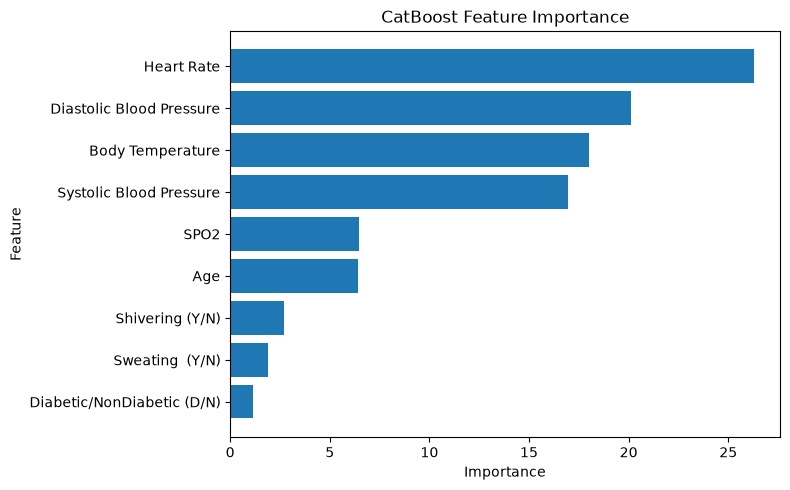

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [44]:
# Make a copy
df_fe = df.copy()

# -----------------------------
# 1. Pulse Pressure
# -----------------------------
df_fe["Pulse Pressure"] = (
    df_fe["Systolic Blood Pressure"]
    - df_fe["Diastolic Blood Pressure"]
)

# -----------------------------
# 2. Mean Arterial Pressure
# -----------------------------
df_fe["MAP"] = (
    df_fe["Diastolic Blood Pressure"]
    + (
        df_fe["Systolic Blood Pressure"]
        - df_fe["Diastolic Blood Pressure"]
    ) / 3
)

# -----------------------------
# 3. Heart Rate × Sweating
# -----------------------------
df_fe["HR_Sweating"] = (
    df_fe["Heart Rate"]
    * df_fe["Sweating  (Y/N)"]
)

# -----------------------------
# 4. Heart Rate × Shivering
# -----------------------------
df_fe["HR_Shivering"] = (
    df_fe["Heart Rate"]
    * df_fe["Shivering (Y/N)"]
)

# -----------------------------
# 5. SBP / DBP ratio
# -----------------------------
df_fe["BP_Ratio"] = (
    df_fe["Systolic Blood Pressure"]
    / df_fe["Diastolic Blood Pressure"]
)

# Check the new features
print(df_fe[
    [
        "Pulse Pressure",
        "MAP",
        "HR_Sweating",
        "HR_Shivering",
        "BP_Ratio"
    ]
].describe())

       Pulse Pressure           MAP   HR_Sweating  HR_Shivering      BP_Ratio
count    16697.000000  16697.000000  16697.000000  16697.000000  16697.000000
mean        41.094209     90.789044     12.547224     15.194406      1.544167
std          9.232810      5.981117     33.617663     36.716843      0.155036
min         20.000000     71.666667      0.000000      0.000000      1.206186
25%         34.000000     86.666667      0.000000      0.000000      1.425287
50%         41.000000     90.666667      0.000000      0.000000      1.536232
75%         48.000000     95.333333      0.000000      0.000000      1.653846
max         77.000000    113.000000    120.000000    130.000000      2.132353


In [45]:
print("\nMissing values:")
print(
    df_fe[
        [
            "Pulse Pressure",
            "MAP",
            "HR_Sweating",
            "HR_Shivering",
            "BP_Ratio"
        ]
    ].isnull().sum()
)


Missing values:
Pulse Pressure    0
MAP               0
HR_Sweating       0
HR_Shivering      0
BP_Ratio          0
dtype: int64


In [46]:
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --------------------------------------------------
# 1. Define features INCLUDING engineered features
# --------------------------------------------------

features_fe = [
    'Age',
    'Diastolic Blood Pressure',
    'Systolic Blood Pressure',
    'Heart Rate',
    'Body Temperature',
    'SPO2',
    'Sweating  (Y/N)',
    'Shivering (Y/N)',
    'Diabetic/NonDiabetic (D/N)',

    # New features
    'Pulse Pressure',
    'MAP',
    'HR_Sweating',
    'HR_Shivering',
    'BP_Ratio'
]

target = 'Blood Glucose Level(BGL)'

X_fe = df_fe[features_fe]
y_fe = df_fe[target]

# --------------------------------------------------
# 2. Same 70/15/15 split strategy you used
# --------------------------------------------------

X_train_fe, X_temp_fe, y_train_fe, y_temp_fe = train_test_split(
    X_fe,
    y_fe,
    test_size=0.30,
    random_state=42,
    stratify=df_fe.loc[X_fe.index, "Age"]
)

X_val_fe, X_test_fe, y_val_fe, y_test_fe = train_test_split(
    X_temp_fe,
    y_temp_fe,
    test_size=0.50,
    random_state=42,
    stratify=X_temp_fe["Age"]
)

# --------------------------------------------------
# 3. Train CatBoost
# --------------------------------------------------

cat_fe = CatBoostRegressor(
    loss_function='RMSE',
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    random_seed=42,
    verbose=False
)

cat_fe.fit(
    X_train_fe,
    y_train_fe,
    eval_set=(X_val_fe, y_val_fe),
    verbose=False
)

# --------------------------------------------------
# 4. Validation prediction
# --------------------------------------------------

cat_fe_val_pred = cat_fe.predict(X_val_fe)

# --------------------------------------------------
# 5. Evaluation
# --------------------------------------------------

rmse = np.sqrt(
    mean_squared_error(y_val_fe, cat_fe_val_pred)
)

mae = mean_absolute_error(
    y_val_fe,
    cat_fe_val_pred
)

r2 = r2_score(
    y_val_fe,
    cat_fe_val_pred
)

print("CatBoost with engineered features")
print("----------------------------------")
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

CatBoost with engineered features
----------------------------------
RMSE: 40.023159239166944
MAE : 22.08837186291154
R²  : 0.22380570271419653


In [47]:
from catboost import CatBoostRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --------------------------------------------------
# Use original features
# --------------------------------------------------

features = [
    'Age',
    'Diastolic Blood Pressure',
    'Systolic Blood Pressure',
    'Heart Rate',
    'Body Temperature',
    'SPO2',
    'Sweating  (Y/N)',
    'Shivering (Y/N)',
    'Diabetic/NonDiabetic (D/N)'
]

X = df[features]
y = df['Blood Glucose Level(BGL)']

# --------------------------------------------------
# Use the SAME split as before
# --------------------------------------------------

X_train_log, X_temp_log, y_train_log, y_temp_log = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=df.loc[X.index, "Age"]
)

X_val_log, X_test_log, y_val_log, y_test_log = train_test_split(
    X_temp_log,
    y_temp_log,
    test_size=0.50,
    random_state=42,
    stratify=X_temp_log["Age"]
)

# --------------------------------------------------
# Transform ONLY training target
# --------------------------------------------------

y_train_log_transformed = np.log1p(y_train_log)

# --------------------------------------------------
# Train CatBoost on transformed target
# --------------------------------------------------

cat_log = CatBoostRegressor(
    loss_function='RMSE',
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    random_seed=42,
    verbose=False
)

cat_log.fit(
    X_train_log,
    y_train_log_transformed,
    eval_set=(X_val_log, np.log1p(y_val_log)),
    verbose=False
)

# --------------------------------------------------
# Predict in log scale
# --------------------------------------------------

pred_log = cat_log.predict(X_val_log)

# Convert predictions back to original BGL scale
pred_original = np.expm1(pred_log)

# --------------------------------------------------
# Evaluate on ORIGINAL BGL values
# --------------------------------------------------

rmse = np.sqrt(
    mean_squared_error(y_val_log, pred_original)
)

mae = mean_absolute_error(
    y_val_log,
    pred_original
)

r2 = r2_score(
    y_val_log,
    pred_original
)

print("CatBoost + log1p target")
print("-----------------------")
print("RMSE:", rmse)
print("MAE :", mae)
print("R²  :", r2)

CatBoost + log1p target
-----------------------
RMSE: 40.38843972992428
MAE : 20.650868986302548
R²  : 0.20957281937264438


In [48]:
# Correlation of every numerical feature with BGL
# separately for diabetic and non-diabetic groups

numeric_features = [
    'Age',
    'Diastolic Blood Pressure',
    'Systolic Blood Pressure',
    'Heart Rate',
    'Body Temperature',
    'SPO2',
    'Sweating  (Y/N)',
    'Shivering (Y/N)'
]

for status in [0, 1]:

    group = df[
        df['Diabetic/NonDiabetic (D/N)'] == status
    ]

    print("\n====================================")
    print(
        "NON-DIABETIC"
        if status == 0
        else "DIABETIC"
    )
    print("Samples:", len(group))
    print("====================================")

    correlations = (
        group[numeric_features + ['Blood Glucose Level(BGL)']]
        .corr()['Blood Glucose Level(BGL)']
        .drop('Blood Glucose Level(BGL)')
        .sort_values(ascending=False)
    )

    print(correlations)


NON-DIABETIC
Samples: 328
Age                         0.624865
Systolic Blood Pressure     0.191929
Diastolic Blood Pressure    0.096489
SPO2                        0.064561
Heart Rate                 -0.008790
Sweating  (Y/N)            -0.016403
Body Temperature           -0.095472
Shivering (Y/N)                  NaN
Name: Blood Glucose Level(BGL), dtype: float64

DIABETIC
Samples: 16369
Diastolic Blood Pressure    0.315239
Systolic Blood Pressure     0.193126
SPO2                        0.153633
Body Temperature            0.147908
Age                         0.002960
Sweating  (Y/N)            -0.239348
Shivering (Y/N)            -0.292152
Heart Rate                 -0.350981
Name: Blood Glucose Level(BGL), dtype: float64


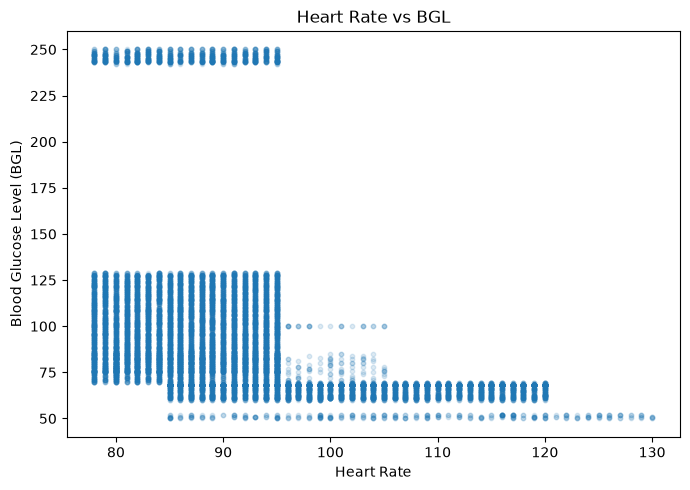

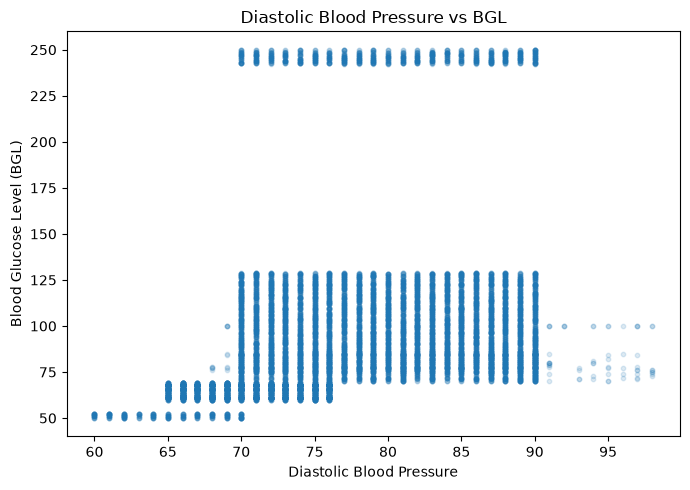

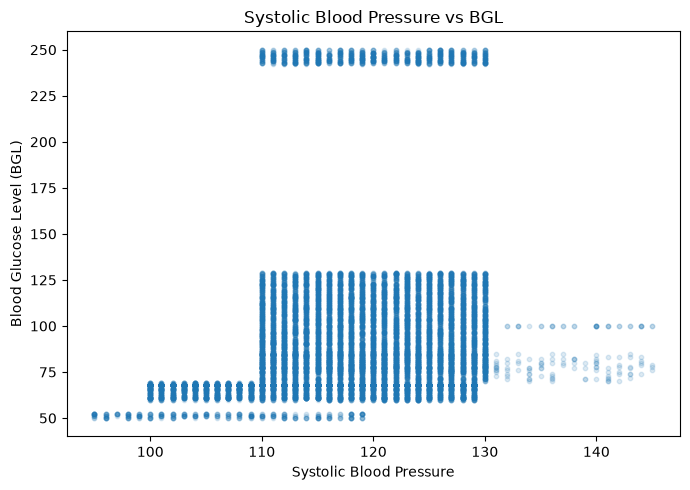

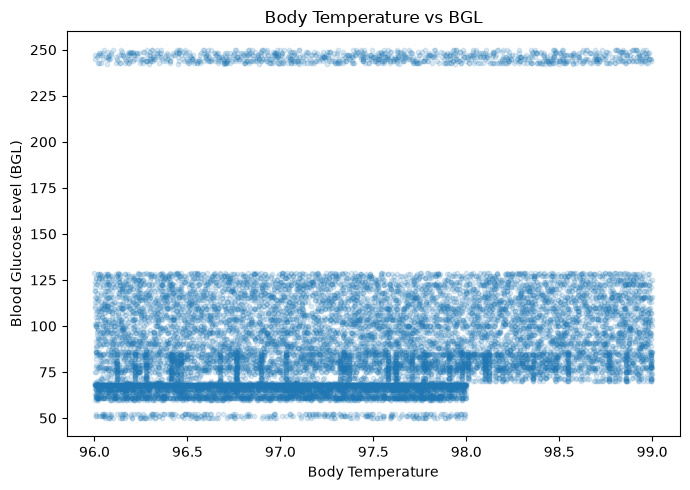

In [49]:
import matplotlib.pyplot as plt

features_to_plot = [
    'Heart Rate',
    'Diastolic Blood Pressure',
    'Systolic Blood Pressure',
    'Body Temperature'
]

for feature in features_to_plot:

    plt.figure(figsize=(7, 5))

    plt.scatter(
        df['{}'.format(feature)],
        df['Blood Glucose Level(BGL)'],
        alpha=0.15,
        s=10
    )

    plt.xlabel(feature)
    plt.ylabel('Blood Glucose Level (BGL)')
    plt.title(f'{feature} vs BGL')

    plt.tight_layout()
    plt.show()

In [50]:
bgl_counts = (
    df["Blood Glucose Level(BGL)"]
    .value_counts()
    .sort_index()
)

print(bgl_counts.to_string())

Blood Glucose Level(BGL)
50       82
51      101
52      118
60      147
61      576
62      342
63      254
64      248
65      306
66      434
67      273
68     2040
69      226
70      129
71      145
72      136
73      121
74      137
75      283
76      269
77      311
78      282
79      250
80      304
81      273
82      275
83      267
84      303
85      290
86      256
87      146
88      162
89      150
90      166
91      164
92      151
93      150
94      161
95      140
96      183
97      133
98      150
99      140
100     219
101     137
102     160
103     159
104     154
105     139
106     163
107     140
108     156
109     160
110     160
111     154
112     137
113     156
114     149
115     139
116     147
117     164
118     137
119     137
120     149
121     123
122     165
123     154
124     145
125     141
126     132
127     171
128     159
129      90
242      15
243     144
244     174
245     147
246     136
247     159
248     103
249      66
250

In [51]:
print("\nMost frequent BGL values:")
print(
    df["Blood Glucose Level(BGL)"]
    .value_counts()
    .head(30)
)


Most frequent BGL values:
Blood Glucose Level(BGL)
68     2040
61      576
66      434
62      342
77      311
65      306
80      304
84      303
85      290
75      283
78      282
82      275
81      273
67      273
76      269
83      267
86      256
63      254
79      250
64      248
69      226
100     219
96      183
244     174
127     171
90      166
122     165
91      164
117     164
106     163
Name: count, dtype: int64


In [52]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# --------------------------------------------------
# Create binary target
# --------------------------------------------------

y_train_high = (y_train >= 200).astype(int)
y_val_high = (y_val >= 200).astype(int)

print("Training class distribution:")
print(y_train_high.value_counts())

print("\nValidation class distribution:")
print(y_val_high.value_counts())


# --------------------------------------------------
# Train CatBoost classifier
# --------------------------------------------------

high_bgl_classifier = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False
)

high_bgl_classifier.fit(
    X_train,
    y_train_high,
    eval_set=(X_val, y_val_high),
    verbose=False
)


# --------------------------------------------------
# Probability of high BGL
# --------------------------------------------------

high_bgl_prob = high_bgl_classifier.predict_proba(X_val)[:, 1]

# Default classification
high_bgl_pred = (high_bgl_prob >= 0.5).astype(int)


# --------------------------------------------------
# Evaluation
# --------------------------------------------------

roc_auc = roc_auc_score(
    y_val_high,
    high_bgl_prob
)

pr_auc = average_precision_score(
    y_val_high,
    high_bgl_prob
)

print("\nROC-AUC:", roc_auc)
print("PR-AUC :", pr_auc)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_val_high,
        high_bgl_pred
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_val_high,
        high_bgl_pred,
        target_names=[
            "BGL < 200",
            "BGL >= 200"
        ]
    )
)

Training class distribution:
Blood Glucose Level(BGL)
0    10972
1      715
Name: count, dtype: int64

Validation class distribution:
Blood Glucose Level(BGL)
0    2328
1     177
Name: count, dtype: int64

ROC-AUC: 0.6885010775234435
PR-AUC : 0.12052662754084863

Confusion Matrix:
[[2328    0]
 [ 177    0]]

Classification Report:
              precision    recall  f1-score   support

   BGL < 200       0.93      1.00      0.96      2328
  BGL >= 200       0.00      0.00      0.00       177

    accuracy                           0.93      2505
   macro avg       0.46      0.50      0.48      2505
weighted avg       0.86      0.93      0.90      2505



c:\Users\C45629B\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\C45629B\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\C45629B\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

In [53]:
from catboost import CatBoostClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# --------------------------------------------------
# Create high-BGL classification target
# --------------------------------------------------

y_train_high = (y_train >= 200).astype(int)
y_val_high = (y_val >= 200).astype(int)

# --------------------------------------------------
# Balanced CatBoost classifier
# --------------------------------------------------

balanced_classifier = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.03,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    auto_class_weights='Balanced',
    random_seed=42,
    verbose=False
)

balanced_classifier.fit(
    X_train,
    y_train_high,
    eval_set=(X_val, y_val_high),
    verbose=False
)

# --------------------------------------------------
# Predict probabilities
# --------------------------------------------------

high_prob = balanced_classifier.predict_proba(X_val)[:, 1]

# --------------------------------------------------
# AUC metrics
# --------------------------------------------------

roc_auc = roc_auc_score(
    y_val_high,
    high_prob
)

pr_auc = average_precision_score(
    y_val_high,
    high_prob
)

print("ROC-AUC:", roc_auc)
print("PR-AUC :", pr_auc)

# --------------------------------------------------
# Check different classification thresholds
# --------------------------------------------------

for threshold in [0.10, 0.20, 0.30, 0.40, 0.50]:

    pred = (high_prob >= threshold).astype(int)

    cm = confusion_matrix(
        y_val_high,
        pred
    )

    print("\nThreshold:", threshold)
    print("Confusion Matrix:")
    print(cm)

    print(
        classification_report(
            y_val_high,
            pred,
            target_names=[
                "BGL < 200",
                "BGL >= 200"
            ],
            zero_division=0
        )
    )

ROC-AUC: 0.6899547634302134
PR-AUC : 0.12282060572855792

Threshold: 0.1
Confusion Matrix:
[[ 646 1682]
 [   0  177]]
              precision    recall  f1-score   support

   BGL < 200       1.00      0.28      0.43      2328
  BGL >= 200       0.10      1.00      0.17       177

    accuracy                           0.33      2505
   macro avg       0.55      0.64      0.30      2505
weighted avg       0.94      0.33      0.42      2505


Threshold: 0.2
Confusion Matrix:
[[ 717 1611]
 [   1  176]]
              precision    recall  f1-score   support

   BGL < 200       1.00      0.31      0.47      2328
  BGL >= 200       0.10      0.99      0.18       177

    accuracy                           0.36      2505
   macro avg       0.55      0.65      0.33      2505
weighted avg       0.94      0.36      0.45      2505


Threshold: 0.3
Confusion Matrix:
[[ 738 1590]
 [   1  176]]
              precision    recall  f1-score   support

   BGL < 200       1.00      0.32      0.48      23